In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, glob, os
import scipy.stats as stats, scipy.io as sio
from statsmodels.stats.multitest import fdrcorrection
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from matplotlib.colors import Normalize

%matplotlib inline

### Objective
0. Run after neur4.ipynb
1. Plot boundary_context in PC space
2. Plot shape in PC space
3. Decode boundary_context & shape
4. Decode shape cross-context with optimal bias shift
5. Are context reps linearly shifted? (centroid collinearity + ordering)
6. Shape in context-aligned PC space
7. Shape decoding from top-k shape-selective neurons
8. Shape decoding after projecting out context axis
9. Regression decoding of stim_pos_aligned (continuous)

### variables

In [2]:
patient = 22
epoch   = 'stim'


### helpers (from neur4)

In [3]:
psychopy_df = pd.read_csv('../../results/psychopy/all_subjs_clean.csv')
psychopy_df = psychopy_df[['trial_key', *psychopy_df.columns.difference(['trial_key'], sort=False)]]


In [4]:
def get_pt_metadata(patient, verbose=True):
    pt_data_dir = f'../../results/2025{patient}/records/processed_data'
    pt_psychopy_df = psychopy_df.loc[psychopy_df['subj'] == patient].reset_index(drop=True)
    pt_neur_df     = pd.read_parquet(f'{pt_data_dir}/df_neurs.parquet')
    pt_num_neurs   = len(pt_neur_df)
    if verbose: print(f'patient={patient}', f'num_trials={len(pt_psychopy_df)}', f'num_neurons={pt_num_neurs}\n')
    return pt_psychopy_df, pt_neur_df, pt_num_neurs


def get_pt_epoch_spike_data(patient, epoch, verbose=True):
    pt_data_dir = f'../../results/2025{patient}/records/processed_data'
    pt_epoch_spikes     = np.load(f'{pt_data_dir}/{epoch}_spikes.npy', allow_pickle=True)
    pt_epoch_num_spikes = np.array([[len(pt_epoch_spikes[t, n]) for n in range(pt_epoch_spikes.shape[1])]
                                    for t in range(pt_epoch_spikes.shape[0])])
    pt_epoch_FRs  = np.load(f'{pt_data_dir}/{epoch}_FRs.npy', allow_pickle=True)
    pt_epoch_bins = np.load(f'{pt_data_dir}/{epoch}_bin_centers.npy', allow_pickle=True)
    if verbose:
        print(f'patient={patient}, epoch={epoch}')
        print(f'spikes (trials, neurons): {pt_epoch_spikes.shape}')
        print(f'FRs (trials, neurons, bins): {pt_epoch_FRs.shape}')
    return pt_epoch_spikes, pt_epoch_num_spikes, pt_epoch_FRs, pt_epoch_bins


def get_contrast_in_epoch(psychopy_df, contrast, verbose=True):
    cont_trials, cont_labels = [], []
    if contrast == 'boundary_context':
        for cond in ['curv_comp', 'baseline', 'flat_comp']:
            cont_trials.append(psychopy_df[psychopy_df['condition'] == cond].index)
            cont_labels.append(cond)
    elif contrast == 'shape':
        cont_trials.append(psychopy_df[psychopy_df['shape'] == 'curv'].index)
        cont_trials.append(psychopy_df[psychopy_df['shape'] == 'flat'].index)
        cont_labels += ['curv', 'flat']
    elif contrast == 'valence':
        cont_trials.append(psychopy_df[psychopy_df['stim_pos_aligned'] > psychopy_df['div_pos_aligned']].index)
        cont_trials.append(psychopy_df[psychopy_df['stim_pos_aligned'] < psychopy_df['div_pos_aligned']].index)
        cont_labels += ['gain', 'loss']
    if verbose: print(f'contrast: {contrast}')
    return cont_trials, cont_labels


### load patient data & build (trials x neurons) FR matrix

In [5]:
patients_neural = [p for p in psychopy_df['subj'].unique() if p not in [9, 11]]

X_list = []
ref_psychopy_df = None

for pt in patients_neural:
    pt_psychopy_df, _, _ = get_pt_metadata(pt, verbose=False)
    _, _, pt_epoch_FRs, pt_epoch_bins = get_pt_epoch_spike_data(pt, epoch, verbose=False)

    # sort by trial_key to align across patients
    sort_order = pt_psychopy_df['trial_key'].argsort().values
    pt_psychopy_df = pt_psychopy_df.iloc[sort_order].reset_index(drop=True)
    pt_FRs_sorted  = pt_epoch_FRs[sort_order]

    # assert trial alignment
    if ref_psychopy_df is None:
        ref_psychopy_df = pt_psychopy_df
    else:
        assert np.array_equal(pt_psychopy_df['trial_key'].values, ref_psychopy_df['trial_key'].values), \
            f'trial_key mismatch for patient {pt}'

    # average FRs over time bins -> (trials, neurons), append
    X_list.append(pt_FRs_sorted.mean(axis=2))
    print(f'pt{pt}: {pt_FRs_sorted.shape[1]} neurons')

# mega-patient: hstack neurons across patients
X = np.hstack(X_list)  # (trials, total_neurons)

# trial labels from reference patient (same trial order for all)
ctx_label = ref_psychopy_df['condition'].copy()
y_shape   = (ref_psychopy_df['shape'] == 'curv').astype(int).values

print(f'\nX shape (trials, total_neurons): {X.shape}')
print(f'context counts: {ctx_label.value_counts().to_dict()}')


pt12: 32 neurons
pt18: 23 neurons
pt21: 10 neurons
pt22: 10 neurons

X shape (trials, total_neurons): (240, 75)
context counts: {'baseline': 80, 'curv_comp': 80, 'flat_comp': 80}


### 1. boundary_context in PC space

explained variance:
  PC1: 18.6%
  PC2: 17.7%
  PC3: 10.1%


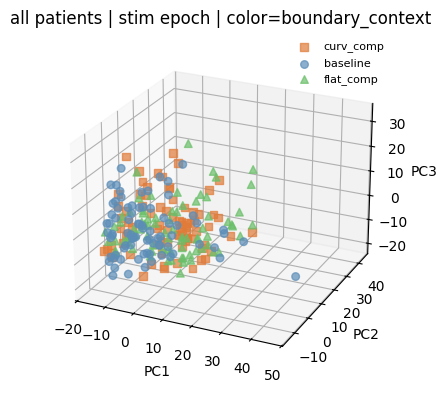

In [6]:
pca = PCA(n_components=3)
pcs = pca.fit_transform(X)

print('explained variance:')
for i, v in enumerate(pca.explained_variance_ratio_, 1): print(f'  PC{i}: {v*100:.1f}%')

# SETTINGS
view_elev, view_azim = 24, -65

# plot
cond_colors  = {'curv_comp': '#e07b39', 'baseline': '#5b8db8', 'flat_comp': '#6abf69'}
cond_markers = {'curv_comp': 's', 'baseline': 'o', 'flat_comp': '^'}

fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111, projection='3d')
for cond in ['curv_comp', 'baseline', 'flat_comp']:
    mask = ctx_label == cond
    ax.scatter(pcs[mask, 0], pcs[mask, 1], pcs[mask, 2],
               color=cond_colors[cond], marker=cond_markers[cond],
               s=30, alpha=0.7, label=cond)
ax.view_init(elev=view_elev, azim=view_azim)
ax.set(xlabel='PC1', ylabel='PC2', zlabel='PC3',
       title=f'all patients | {epoch} epoch | color=boundary_context')
ax.legend(fontsize=8, frameon=False)
plt.tight_layout()
plt.show()


### 2. shape in PC space

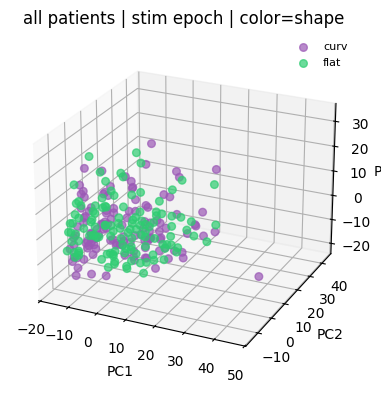

In [7]:
shape_colors = {'curv': '#9b59b6', 'flat': '#2ecc71'}

fig = plt.figure(figsize=(6, 4))
ax = fig.add_subplot(111, projection='3d')
for shp, color in shape_colors.items():
    mask = ref_psychopy_df['shape'] == shp
    ax.scatter(pcs[mask, 0], pcs[mask, 1], pcs[mask, 2],
               color=color, s=30, alpha=0.7, label=shp)
ax.view_init(elev=view_elev, azim=view_azim)
ax.set(xlabel='PC1', ylabel='PC2', zlabel='PC3',
       title=f'all patients | {epoch} epoch | color=shape')
ax.legend(fontsize=8, frameon=False)
plt.tight_layout()
plt.show()


### 3. decode boundary_context & shape

In [8]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_context = np.array(ctx_label, dtype=str)

# 3. decode boundary_context (3-class, chance=33%)
acc_ctx = cross_val_score(LogisticRegression(penalty=None, max_iter=1000),
                          X, y_context, cv=cv).mean()
print(f'boundary_context decoding: {acc_ctx*100:.1f}%  (chance=33%)')

# 4. decode shape (binary, chance=50%)
acc_shp = cross_val_score(LogisticRegression(penalty=None, max_iter=1000),
                          X, y_shape, cv=cv).mean()
print(f'shape decoding: {acc_shp*100:.1f}%  (chance=50%)')


boundary_context decoding: 46.2%  (chance=33%)
shape decoding: 52.5%  (chance=50%)


### 4. cross-context shape decoding (bias-shifted)

In [9]:
from itertools import permutations

contexts  = np.unique(y_context)
bias_grid = np.linspace(-5, 5, 200)

no_shift_accs, shift_accs, centroid_accs = [], [], []

for train_ctx, test_ctx in permutations(contexts, 2):
    train_mask = y_context == train_ctx
    test_mask  = y_context == test_ctx

    X_train = X[train_mask]
    X_test  = X[test_mask]

    clf = LogisticRegression(C=0.01, max_iter=1000)
    clf.fit(X_train, y_shape[train_mask])

    dv = (X_test @ clf.coef_.T + clf.intercept_).ravel()

    # no shift
    no_shift_accs.append(((dv > 0) == y_shape[test_mask]).mean())

    # bias shift: scan scalar offset on decision function
    best_acc = max(((dv + delta > 0) == y_shape[test_mask]).mean() for delta in bias_grid)
    shift_accs.append(best_acc)

    # centroid correction: subtract full centroid difference vector
    delta_vec = X_test.mean(axis=0) - X_train.mean(axis=0)
    X_test_corrected = X_test - delta_vec
    centroid_accs.append(clf.score(X_test_corrected, y_shape[test_mask]))

print(f'shape decoding (within-context CV):              {acc_shp*100:.1f}%  (chance=50%)')
print(f'shape decoding (cross-context, no correction):   {np.mean(no_shift_accs)*100:.1f}%')
print(f'shape decoding (cross-context, bias shift):      {np.mean(shift_accs)*100:.1f}%')
print(f'shape decoding (cross-context, centroid corr):   {np.mean(centroid_accs)*100:.1f}%')

shape decoding (within-context CV):              52.5%  (chance=50%)
shape decoding (cross-context, no correction):   48.1%
shape decoding (cross-context, bias shift):      54.6%
shape decoding (cross-context, centroid corr):   48.3%


### 5. are context reps linearly shifted?
If the 3 per-context centroids are collinear, context acts as a 1D translation in neural space (linear shift). Check by running PCA on the 3 centroid vectors — if PC1 ≈ 100%, they're collinear.

Explained variance of context centroids:
  PC1: 77.6%
  PC2: 22.4%
  PC3: 0.0%

Centroid ordering along PC1:
  1. baseline      PC1=-5.247  PC2=-0.392
  2. curv_comp     PC1=1.991  PC2=2.634
  3. flat_comp     PC1=3.256  PC2=-2.242

→ middle along PC1: curv_comp
→ middle along PC2: baseline


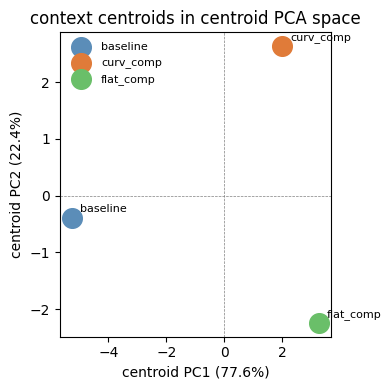

In [10]:
ctx_centroids = np.array([X[y_context == ctx].mean(axis=0) for ctx in np.unique(y_context)])  # (3, 75)
ctx_names = np.unique(y_context)

pca_cent = PCA()
pca_cent.fit(ctx_centroids)
ev = pca_cent.explained_variance_ratio_

print('Explained variance of context centroids:')
for i, v in enumerate(ev, 1):
    print(f'  PC{i}: {v*100:.1f}%')

cent_proj = pca_cent.transform(ctx_centroids)  # (3, 3)
order = np.argsort(cent_proj[:, 0])
print('\nCentroid ordering along PC1:')
for rank, idx in enumerate(order):
    print(f'  {rank+1}. {ctx_names[idx]:12s}  PC1={cent_proj[idx,0]:.3f}  PC2={cent_proj[idx,1]:.3f}')
print(f'\n→ middle along PC1: {ctx_names[order[1]]}')
order2 = np.argsort(cent_proj[:, 1])
print(f'→ middle along PC2: {ctx_names[order2[1]]}')

cond_colors = {'curv_comp': '#e07b39', 'baseline': '#5b8db8', 'flat_comp': '#6abf69'}

fig, ax = plt.subplots(figsize=(4, 4))
for i, ctx in enumerate(ctx_names):
    ax.scatter(cent_proj[i, 0], cent_proj[i, 1],
               color=cond_colors[ctx], s=200, zorder=5, label=ctx)
    ax.annotate(ctx, (cent_proj[i, 0], cent_proj[i, 1]),
                textcoords='offset points', xytext=(6, 4), fontsize=8)
ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.axvline(0, color='gray', lw=0.5, ls='--')
ax.set(xlabel=f'centroid PC1 ({ev[0]*100:.1f}%)', ylabel=f'centroid PC2 ({ev[1]*100:.1f}%)',
       title='context centroids in centroid PCA space')
ax.legend(fontsize=8, frameon=False)
plt.tight_layout()
plt.savefig('/tmp/centroid_pca.png', dpi=150)
plt.show()

### 6. shape in context-aligned PC space
Subtract per-context mean from X, then replot shape. If context was a linear shift, shape structure should become cleaner after alignment.

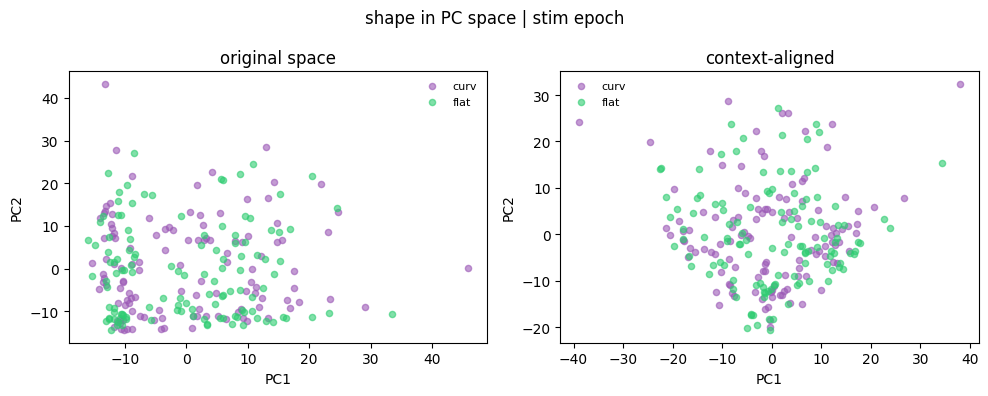

shape decoding original:       52.5%
shape decoding context-aligned:52.5%


In [11]:
X_aligned = X.copy()
for ctx in np.unique(y_context):
    idx = y_context == ctx
    X_aligned[idx] -= X_aligned[idx].mean(axis=0)

pca_aln = PCA(n_components=2)
pcs_aln = pca_aln.fit_transform(X_aligned)
pcs_orig = pcs[:, :2]  # reuse PCA from section 1

shape_colors = {'curv': '#9b59b6', 'flat': '#2ecc71'}

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (pcs_use, title) in zip(axes, [(pcs_orig, 'original space'), (pcs_aln, 'context-aligned')]):
    for shp, color in shape_colors.items():
        mask = ref_psychopy_df['shape'] == shp
        ax.scatter(pcs_use[mask, 0], pcs_use[mask, 1], color=color, s=20, alpha=0.6, label=shp)
    ax.set(title=title, xlabel='PC1', ylabel='PC2')
    ax.legend(fontsize=8, frameon=False)
plt.suptitle(f'shape in PC space | {epoch} epoch')
plt.tight_layout()
plt.show()

acc_shp_aligned = cross_val_score(LogisticRegression(penalty=None, max_iter=1000),
                                  X_aligned, y_shape, cv=cv).mean()
print(f'shape decoding original:       {acc_shp*100:.1f}%')
print(f'shape decoding context-aligned:{acc_shp_aligned*100:.1f}%')

### 7. shape decoding from top-k shape-selective neurons
Rank neurons by |mean(curv) - mean(flat)| and decode shape from the top-k. Avoids noise from unselective neurons.

In [12]:
neuron_selectivity = np.abs(X[y_shape == 1].mean(0) - X[y_shape == 0].mean(0))

print('shape decoding from top-k shape-selective neurons:')
for k in [5, 10, 20, 40, 75]:
    top_k = np.argsort(neuron_selectivity)[-k:]
    acc_k = cross_val_score(LogisticRegression(penalty=None, max_iter=1000),
                            X[:, top_k], y_shape, cv=cv).mean()
    print(f'  top-{k:3d} neurons: {acc_k*100:.1f}%')

shape decoding from top-k shape-selective neurons:
  top-  5 neurons: 58.8%
  top- 10 neurons: 55.0%
  top- 20 neurons: 57.5%
  top- 40 neurons: 54.2%
  top- 75 neurons: 52.5%


### 8. shape decoding after projecting out context axis
Fit a context classifier, extract its weight vectors, find their dominant direction (PC1), and remove that component from X before decoding shape. This explicitly strips out context-driven variance.

In [13]:
clf_ctx = LogisticRegression(penalty=None, max_iter=2000)
clf_ctx.fit(X, y_context)

# dominant direction of the context weight matrix
w_axis = PCA(n_components=1).fit(clf_ctx.coef_).components_[0]  # (75,)

# project out that direction from X
X_ctx_removed = X - (X @ w_axis[:, None]) * w_axis[None, :]

acc_ctx_removed = cross_val_score(LogisticRegression(penalty=None, max_iter=1000),
                                  X_ctx_removed, y_shape, cv=cv).mean()
print(f'shape decoding (original):              {acc_shp*100:.1f}%')
print(f'shape decoding (context axis removed):  {acc_ctx_removed*100:.1f}%')

shape decoding (original):              52.5%
shape decoding (context axis removed):  52.1%


### 9. is the shape axis shared across contexts?
Fit a shape classifier within each context separately. If the brain reuses the same shape axis, the weight vectors should point in similar directions (cosine similarity ≈ 1). Then project context centroids onto the shared axis — if they project near zero, context shifts are orthogonal to the shape axis.

In [14]:
contexts = np.unique(y_context)

# fit within-context shape classifiers, store normalized weight vectors
shape_weights = {}
for ctx in contexts:
    mask = y_context == ctx
    clf = LogisticRegression(C=0.01, max_iter=1000)
    clf.fit(X[mask], y_shape[mask])
    w = clf.coef_[0]
    shape_weights[ctx] = w / np.linalg.norm(w)

# pairwise cosine similarities between shape axes
print('Cosine similarity between within-context shape axes:')
ctx_list = list(contexts)
for i in range(len(ctx_list)):
    for j in range(i+1, len(ctx_list)):
        c1, c2 = ctx_list[i], ctx_list[j]
        cos_sim = np.dot(shape_weights[c1], shape_weights[c2])
        print(f'  {c1:12s} vs {c2:12s}: {cos_sim:.3f}')

# shared shape axis: first PC of the 3 weight vectors
W = np.stack(list(shape_weights.values()))  # (3, 75)
shared_axis = PCA(n_components=1).fit(W).components_[0]
shared_axis /= np.linalg.norm(shared_axis)

# project context centroids onto shared shape axis
print('\nContext centroid projection onto shared shape axis:')
for ctx in contexts:
    centroid = X[y_context == ctx].mean(axis=0)
    proj = np.dot(centroid, shared_axis)
    print(f'  {ctx:12s}: {proj:.3f}')

# within-context shape decoding using shared axis (no per-context fitting)
print('\nWithin-context shape decoding via shared axis (threshold at median):')
for ctx in contexts:
    mask = y_context == ctx
    proj = X[mask] @ shared_axis
    preds = (proj > np.median(proj)).astype(int)
    acc = (preds == y_shape[mask]).mean()
    print(f'  {ctx:12s}: {acc*100:.1f}%')

Cosine similarity between within-context shape axes:
  baseline     vs curv_comp   : -0.027
  baseline     vs flat_comp   : 0.051
  curv_comp    vs flat_comp   : -0.071

Context centroid projection onto shared shape axis:
  baseline    : -4.905
  curv_comp   : -5.290
  flat_comp   : -4.808

Within-context shape decoding via shared axis (threshold at median):
  baseline    : 40.0%
  curv_comp   : 72.5%
  flat_comp   : 32.5%


### 10. regression decoding of stim_aligned_to_div
Ridge regression on continuous stim position relative to boundary. R² > 0 = above-chance.

In [15]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold

cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)
y_stim = ref_psychopy_df['stim_aligned_to_div'].values  # stim pos relative to boundary

r2_all = cross_val_score(Ridge(), X, y_stim, cv=cv_reg, scoring='r2').mean()
print(f'stim_aligned_to_div R² (all neurons):    {r2_all:.3f}')

top5 = np.argsort(neuron_selectivity)[-5:]
r2_top5 = cross_val_score(Ridge(), X[:, top5], y_stim, cv=cv_reg, scoring='r2').mean()
print(f'stim_aligned_to_div R² (top-5 neurons):  {r2_top5:.3f}')

ctx_r2s = []
for train_ctx, test_ctx in permutations(np.unique(y_context), 2):
    train_mask = y_context == train_ctx
    test_mask  = y_context == test_ctx
    reg = Ridge()
    reg.fit(X[train_mask], y_stim[train_mask])
    ss_res = ((y_stim[test_mask] - reg.predict(X[test_mask]))**2).sum()
    ss_tot = ((y_stim[test_mask] - y_stim[test_mask].mean())**2).sum()
    ctx_r2s.append(1 - ss_res / ss_tot)
print(f'stim_aligned_to_div R² (cross-context):  {np.mean(ctx_r2s):.3f}')

stim_aligned_to_div R² (all neurons):    -0.694
stim_aligned_to_div R² (top-5 neurons):  -0.025
stim_aligned_to_div R² (cross-context):  -4.983
